In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure
import h5py

# 1. Create a 3D grid and a scalar field (e.g., a sphere)
x, y, z = np.ogrid[-5:5:50j, -5:5:50j, -5:5:50j]
# This formula creates a 3D array of distances from the origin
vol = x**2 + y**2 + z**2

with h5py.File('./r267r268_0003/data/output_010.h5', 'r') as f:
    vol = f['/intens'][0, ...]
# 2. Extract the isosurface using Marching Cubes
# We want the surface where the value equals 9.0 (a sphere of radius 3)

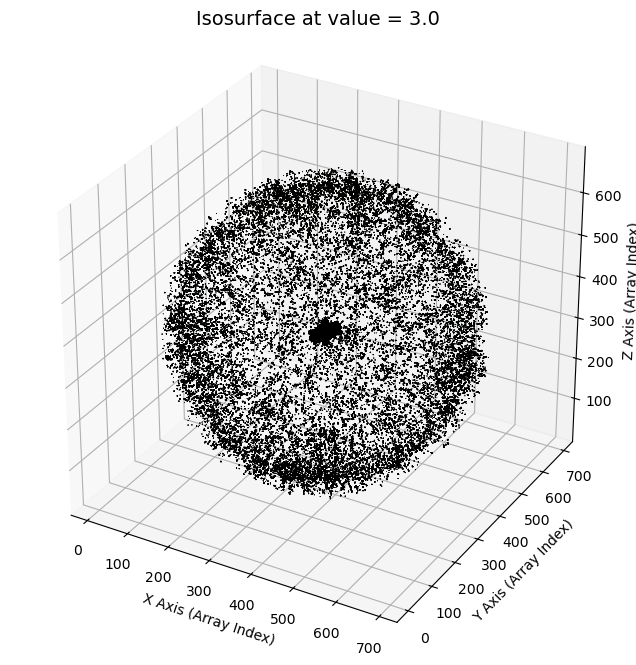

In [5]:
isovalue = 3.0

verts, faces, normals, values = measure.marching_cubes(vol, level=isovalue)

# 3. Set up the Matplotlib 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 4. Plot the surface using Poly3DCollection
# We need to index verts with faces to construct the polygons
mesh = ax.plot_trisurf(
    verts[:, 0], verts[:, 1], faces, verts[:, 2],
    cmap='viridis', lw=0.5, edgecolor='k', alpha=0.8
)

# 5. Labels and styling
ax.set_title(f"Isosurface at value = {isovalue}", fontsize=14)
ax.set_xlabel('X Axis (Array Index)')
ax.set_ylabel('Y Axis (Array Index)')
ax.set_zlabel('Z Axis (Array Index)')

# Equalize the axes so the sphere isn't distorted
ax.set_aspect('equal')

plt.show()

In [96]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from ipywidgets import interactive

dfly_tag = 'r267r268_0003'
niter = 40
ix = 180

with h5py.File(f'./{dfly_tag}/data/output_001.h5', 'r') as f:
    intens_shape = f['/intens'].shape[1:]

plot_array = np.zeros((niter+1, intens_shape[1], intens_shape[2]))

for i in range(0, niter+1):
    with h5py.File(f'./{dfly_tag}/data/output_{i:03}.h5', 'r') as f:
        plot_array[i] = f['/intens'][0, ix, :, :]



def plot_slice(i):
    plt.figure()
    plt.imshow(plot_array[i], clim=(0, 50))
    plt.colorbar()
    plt.xlim([130, 230])
    plt.ylim([130, 230])


p = interactive(plot_slice, i=(0, niter-1, 1))


In [53]:
p

interactive(children=(IntSlider(value=19, description='i', max=39), Output(outputs=({'output_type': 'display_d…

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from ipywidgets import interactive

niter = 50
ix = 180
istart = 90
iend = 180

#with h5py.File(f'./phase/phase-out-long.h5', 'r') as f:
#    recons = f['/recons'].shape[1:]

plot_array = np.zeros((niter, 90, 90))

for i in range(0, niter):
    with h5py.File(f'./phase/phase-out-long.h5', 'r') as f:
        plot_array[i] = f['/recons'][i, 271//2, istart:iend, istart:iend]


plot_array = np.abs(plot_array)**2

def plot_slice(i):
    plt.figure()
    plt.imshow(plot_array[i], clim=(0,0.00004))
    plt.colorbar()
    #plt.xlim([130, 230])
    #plt.ylim([130, 230])


p = interactive(plot_slice, i=(0, niter-1, 1))

/tmp/ipykernel_2042112/285371151.py:18: ComplexWarning: Casting complex values to real discards the imaginary part
  plot_array[i] = f['/recons'][i, 271//2, istart:iend, istart:iend]


In [73]:
p

interactive(children=(IntSlider(value=24, description='i', max=49), Output(outputs=({'output_type': 'display_d…

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from ipywidgets import interactive


istart = 90
iend = 180
nx = iend-istart

plot_array = np.zeros((nx, nx, nx))

for i in range(nx):
    ix = istart+i
    #print(ix)
    with h5py.File(f'./phase/phase-out-long.h5', 'r') as f:
        plot_array[i] = f['/recons'][49, ix, istart:iend, istart:iend]


plot_array = np.abs(plot_array)**2

def plot_slice(i):
    plt.figure()
    plt.imshow(plot_array[i],)# clim=(0,1e-5))
    plt.colorbar()
    #plt.xlim([130, 230])
    #plt.ylim([130, 230])


p = interactive(plot_slice, i=(0, nx, 1))

/tmp/ipykernel_2408050/2509717473.py:17: ComplexWarning: Casting complex values to real discards the imaginary part
  plot_array[i] = f['/recons'][49, ix, istart:iend, istart:iend]


In [6]:
p

interactive(children=(IntSlider(value=45, description='i', max=90), Output(outputs=({'output_type': 'display_d…